# Project 4 - Neural Radiance Field (NeRF)

In [1]:
# load libraries
import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from skimage.transform import resize

import cv2
import numpy as np
import glob # for loading multiple files
import viser # visualizations

## Part 0: Calibrating Your Camera and Capturing a 3D Scan

### Part 0.1: Calibrating Your Camera

In [ ]:
# calibration pipeline

# starter code from spec
# import cv2
# import numpy as np

# Create ArUco dictionary and detector parameters (4x4 tags)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()

# tag size
tag_size = 0.06 # meters, 0.02 = 2 cm
# 3d coordinates of aruco tag in world frame
obj_pts_single = np.array([
    [0, 0, 0],           # Top-left
    [tag_size, 0, 0],    # Top-right
    [tag_size, tag_size, 0],  # Bottom-right
    [0, tag_size, 0]     # Bottom-left
], dtype = np.float32)

obj_pts = [] # all 3D pts in world frame
img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

for path in images:
    # load image
    im = cv2.imread(path)
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Detect ArUco markers in an image
    # Returns: corners (list of numpy arrays), ids (numpy array)
    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

    # Check if any markers were detected
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.")
        continue
    # Process the detected corners
    # corners: list of length N (number of detected tags)
    #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
    # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
    # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
        # loop through all detected markers
    for c in corners:
        img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
        obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# 5. calibrate camera
if len(obj_pts) >= 10:
    print(f"Using {len(obj_pts)} detected tags for calibration")
    img_shape = gray.shape[::-1] # (width, height)
    
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        obj_pts,
        img_pts,
        img_shape,
        None, # initial camera matrix (estimated by OpenCV)
        None # initial distortion coefficients
    )

    print("Calibration successful!")
    print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
    print("Distortion coefficients:\n", dist_coeffs)

else:
    print("No valid markers detected in any image. Calibration unsuccessful.")

In [ ]:
# # test if programs work on spec's sample data
# # calibration pipeline

# # starter code from spec
# # import cv2
# # import numpy as np

# # Create ArUco dictionary and detector parameters (4x4 tags)
# aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
# aruco_params = cv2.aruco.DetectorParameters()

# # tag size
# tag_size = 0.06 # meters, 0.02 = 2 cm
# # 3d coordinates of aruco tag in world frame
# obj_pts_single = np.array([
#     [0, 0, 0],           # Top-left
#     [tag_size, 0, 0],    # Top-right
#     [tag_size, tag_size, 0],  # Bottom-right
#     [0, tag_size, 0]     # Bottom-left
# ], dtype = np.float32)

# obj_pts = [] # all 3D pts in world frame
# img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
# # images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

# for path in images:
#     # load image
#     im = cv2.imread(path)
#     gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

#     # Detect ArUco markers in an image
#     # Returns: corners (list of numpy arrays), ids (numpy array)
#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

#     # Check if any markers were detected
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.")
#         continue
#     # Process the detected corners
#     # corners: list of length N (number of detected tags)
#     #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
#     # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
#     # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
#         # loop through all detected markers
#     for c in corners:
#         img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
#         obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# # 5. calibrate camera
# if len(obj_pts) >= 10:
#     print(f"Using {len(obj_pts)} detected tags for calibration")
#     img_shape = gray.shape[::-1] # (width, height)
    
#     ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
#         obj_pts,
#         img_pts,
#         img_shape,
#         None, # initial camera matrix (estimated by OpenCV)
#         None # initial distortion coefficients
#     )

#     print("Calibration successful!")
#     print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
#     print("Distortion coefficients:\n", dist_coeffs)

# else:
#     print("No valid markers detected in any image. Calibration unsuccessful.")

### Part 0.3: Estimating Camera Pose

In [ ]:
# visualize
server = viser.ViserServer(share=True)

obj_images = glob.glob("octo-images/*.jpg")
obj_images = sorted(obj_images)

# for part 0.4
undistorted_images = []
c2w_matrices = []

# for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
for i, path in enumerate(obj_images): # rn images = calibration images
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
        continue

    # use first marker
    img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

    # outputs = solvePnP(inputs)
    success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
    if not success:
        print(f"PnP failed for {path}, skipping.") # check what's happening
        continue

    R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
    t = tvec.reshape(3, 1)
    R_wc = R.T
    t_wc = -R.T @ t
    c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

    # undistort the image
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs)
    # convert BGR to RGB for NeRF
    undistorted = undistorted[:, :, ::-1]
    # append/save
    undistorted_images.append(undistorted)
    c2w_full = np.eye(4)
    c2w_full[:3, :4] = c2w
    c2w_matrices.append(c2w_full)

    # convert BGR to RGB for viser
    img_rgb = img[:, :, ::-1]

    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
        aspect=gray.shape[1] / gray.shape[0],
        scale=0.02,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=img_rgb
    )


In [ ]:
# # visualize
# server = viser.ViserServer(share=True)

# obj_images = glob.glob("lafufu-images/*.JPG")
# obj_images = sorted(obj_images)

# # for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
# for i, path in enumerate(obj_images): # rn images = calibration images
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
#         continue

#     # use first marker
#     img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

#     # outputs = solvePnP(inputs)
#     success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
#     if not success:
#         print(f"PnP failed for {path}, skipping.") # check what's happening
#         continue

#     R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
#     t = tvec.reshape(3, 1)
#     R_wc = R.T
#     t_wc = -R.T @ t
#     c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

#     # convert BGR to RGB for viser
#     img_rgb = img[:, :, ::-1]

#     server.scene.add_camera_frustum(
#         f"/cameras/{i}",
#         fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
#         aspect=gray.shape[1] / gray.shape[0],
#         scale=0.02,
#         wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
#         position=c2w[:3, 3],
#         image=img_rgb
#     )


### Part 0.4: Undistorting images and creating a dataset

In [ ]:
# after for loop to solve PnP + viser
undistorted_images = np.array(undistorted_images) # (N, H, W, 3)
c2w_matrices = np.array(c2w_matrices) # (N, 4, 4)

# train/test split
# train/val/test = 80/10/10
N = len(undistorted_images)
idx_train = int(0.8 * N)
idx_val = int(0.9 * N)

images_train = undistorted_images[:idx_train]
c2ws_train   = c2w_matrices[:idx_train]

images_val   = undistorted_images[idx_train:idx_val]
c2ws_val     = c2w_matrices[idx_train:idx_val]

c2ws_test    = c2w_matrices[idx_val:]

# use average of fx and fy to extract focal length
focal = float((camera_matrix[0, 0] + camera_matrix[1, 1]) / 2)

# from spec to save dataset
# Package your data (keep images in 0-255 range, they'll be normalized when loaded)
np.savez(
    'my_data.npz',
    images_train=images_train,    # (N_train, H, W, 3)
    c2ws_train=c2ws_train,        # (N_train, 4, 4)
    images_val=images_val,        # (N_val, H, W, 3)
    c2ws_val=c2ws_val,            # (N_val, 4, 4)
    c2ws_test=c2ws_test,          # (N_test, 4, 4)
    focal=focal                   # float
)

print("Saved dataset to my_data.npz")

## Part 1: Fit a Neural Field to a 2D Image


--- RUN: PE L=4, width=32 ---
iter 1/2000: loss=0.106142 -> saved part1_results/recon_pe4_w32_iter0001.png
iter 200/2000: loss=0.018015, val_psnr=18.12 dB -> saved part1_results/recon_pe4_w32_iter0200.png
iter 400/2000: loss=0.014087, val_psnr=18.96 dB -> saved part1_results/recon_pe4_w32_iter0400.png
iter 600/2000: loss=0.012064, val_psnr=20.12 dB -> saved part1_results/recon_pe4_w32_iter0600.png
iter 800/2000: loss=0.008342, val_psnr=20.56 dB -> saved part1_results/recon_pe4_w32_iter0800.png
iter 1000/2000: loss=0.006579, val_psnr=22.13 dB -> saved part1_results/recon_pe4_w32_iter1000.png
iter 1200/2000: loss=0.005783, val_psnr=22.67 dB -> saved part1_results/recon_pe4_w32_iter1200.png
iter 1400/2000: loss=0.005898, val_psnr=22.31 dB -> saved part1_results/recon_pe4_w32_iter1400.png
iter 1600/2000: loss=0.005367, val_psnr=22.81 dB -> saved part1_results/recon_pe4_w32_iter1600.png
iter 1800/2000: loss=0.005275, val_psnr=23.30 dB -> saved part1_results/recon_pe4_w32_iter1800.png
iter 

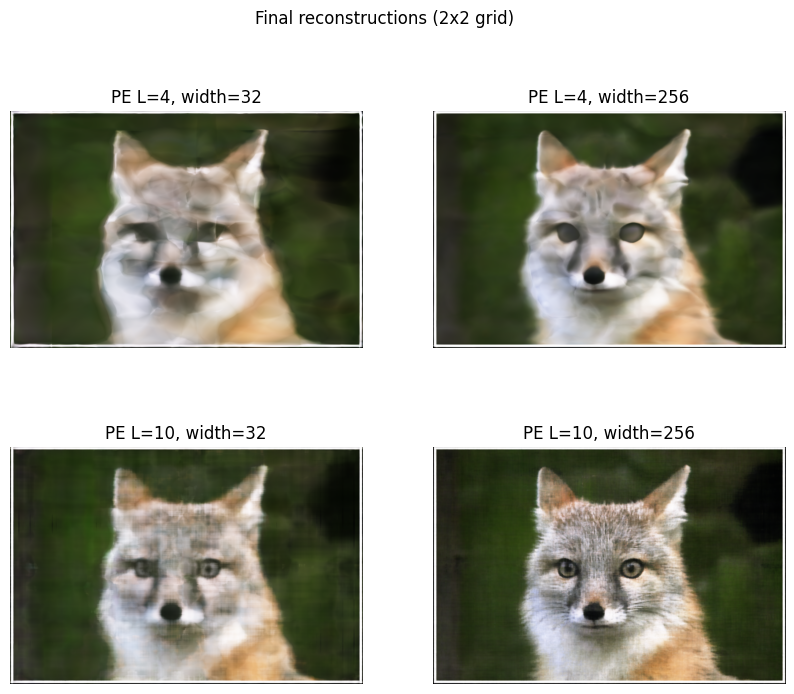

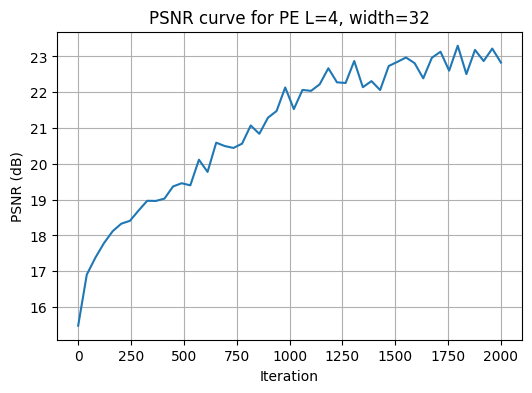

Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).


In [ ]:
import os
import math
import time
from functools import partial

from PIL import Image

# pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


image_path = "fox.jpg" # path to our image
device = torch.device("mps" if torch.mps.is_available() else "cpu") # using mps for m1 mac
out_dir = "part1_results"
os.makedirs(out_dir, exist_ok=True)

# training hyperparams
num_iters = 2000          
batch_size = 10000 # sample pixels per iteration
lr = 1e-2
log_every = 200 # save recon every `log_every` iterations

# hyperparameters
default_width = 256
default_layers = 3 # number of hidden linear layers (as in figure)
default_pe_L = 10  # max frequency L (PE will use 2^0..2^(L-1))

# helper functions
def load_image_np(path):
    im = Image.open(path).convert("RGB")
    arr = np.array(im).astype(np.uint8)
    return arr

def img_to_coords_and_colors(img_np):
    H, W = img_np.shape[:2]
    # create pixel coordinates (x,y) convention: center or top-left? Here we normalize by width/height
    xs = np.arange(W)
    ys = np.arange(H)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2) # (H*W, 2)
    colors = img_np.reshape(-1, 3) / 255.0 # normalize to [0,1]
    return coords.astype(np.float32), colors.astype(np.float32), H, W

def compute_psnr(mse):
    # image normalized [0,1]
    if mse <= 0:
        return float("inf")
    return 10.0 * math.log10(1.0 / mse)

# positional encoding
class PositionalEncoding2D(nn.Module):
    def __init__(self, L):
        """
        L: number of frequencies. Produces features:
           [x, y, sin(2^0 pi x), cos(2^0 pi x), ..., sin(2^(L-1) pi x), cos(2^(L-1) pi x),
                  sin(2^0 pi y), cos(2^0 pi y), ..., sin(2^(L-1) pi y), cos(2^(L-1) pi y)]
           The original coordinate (x,y) is kept as well.
        """
        super().__init__()
        self.L = L
        # precompute scales: 2^k * pi
        self.register_buffer("scales", torch.tensor([ (2**k) * math.pi for k in range(L) ], dtype=torch.float32))

    def forward(self, coords_norm):
        # coords_norm: (N, 2) where coords are normalized to [0,1]
        x = coords_norm[..., 0:1]  # (N,1)
        y = coords_norm[..., 1:2]
        out = [x, y]
        for s in self.scales:
            out.append(torch.sin(x * s))
            out.append(torch.cos(x * s))
        for s in self.scales:
            out.append(torch.sin(y * s))
            out.append(torch.cos(y * s))
        return torch.cat(out, dim=-1)  # (N, 2 + 4*L)

# MLP network
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, width=256, hidden_layers=3):
        super().__init__()
        layers = []
        last = in_dim
        for i in range(hidden_layers):
            layers.append(nn.Linear(last, width))
            layers.append(nn.ReLU(inplace=True))
            last = width
        # final linear to 3 channels
        layers.append(nn.Linear(last, 3))
        layers.append(nn.Sigmoid())  # outputs in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# dataloader
class RandomPixelDataset(Dataset):
    def __init__(self, coords, colors):
        """
        coords: (Npix, 2) in pixel coords (0..W-1, 0..H-1)
        colors: (Npix, 3) normalized [0,1]
        """
        self.coords = coords
        self.colors = colors
        self.N = coords.shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        return self.coords[idx], self.colors[idx]

# run function
def train_single_run(image_path,
                     pe_L=10,
                     width=256,
                     hidden_layers=3,
                     num_iters=2000,
                     batch_size=10000, # staff on Ed recommends a batch size of 10k pixels
                     lr=1e-2, # Ed-recommended learning rate
                     log_every=200,
                     out_dir="part1_results"):
    np_img = load_image_np(image_path)
    coords, colors, H, W = img_to_coords_and_colors(np_img)
    Npix = coords.shape[0]

    # normalize coords to [0,1]
    coords_norm = coords.copy()
    coords_norm[:, 0] = coords_norm[:, 0] / (W - 1)  # x / (W-1)
    coords_norm[:, 1] = coords_norm[:, 1] / (H - 1)  # y / (H-1)

    device_local = device

    # prepare PE and model
    pe = PositionalEncoding2D(pe_L).to(device_local)
    # input dimension after PE == 2 + 4*L
    in_dim = 2 + 4 * pe_L
    model = SimpleMLP(in_dim, width=width, hidden_layers=hidden_layers).to(device_local)

    # optimizer + loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # prepare dataset arrays as tensors (we will sample indices each iteration)
    coords_norm_t = torch.from_numpy(coords_norm).to(device_local)   # (Npix,2)
    colors_t = torch.from_numpy(colors).to(device_local)             # (Npix,3)

    losses = []
    psnrs = []
    start_time = time.time()

    # for monitoring, create a fixed validation set (1000 random pixels)
    rng = np.random.RandomState(123)
    val_idx = rng.choice(Npix, size=min(1000, Npix), replace=False)
    val_coords = coords_norm_t[val_idx]
    val_colors = colors_t[val_idx]

    # main training loop
    for it in range(1, num_iters + 1):
        # sample pixel indices
        idx = np.random.randint(0, Npix, size=batch_size)
        batch_coords = coords_norm_t[idx]  # (batch,2)
        batch_colors = colors_t[idx]       # (batch,3)

        # forward
        pe_feats = pe(batch_coords)        # (batch, in_dim)
        preds = model(pe_feats)            # (batch,3)

        loss = criterion(preds, batch_colors)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # validation PSNR every iteration or per log
        if it % max(1, log_every // 5) == 0:
            with torch.no_grad():
                val_preds = model(pe(pe_coords := val_coords))
                val_mse = F.mse_loss(val_preds, val_colors).item()
                val_psnr = compute_psnr(val_mse)
                psnrs.append(val_psnr)

        # save reconstructions periodically
        if it % log_every == 0 or it == 1 or it == num_iters:
            with torch.no_grad():
                # reconstruct full image (may be slow for large images)
                all_pe = pe(coords_norm_t)  # (Npix, in_dim)
                all_preds = model(all_pe).cpu().numpy()  # (Npix,3)
                recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
                out_img_path = os.path.join(out_dir, f"recon_pe{pe_L}_w{width}_iter{it:04d}.png")
                Image.fromarray(recon).save(out_img_path)
                msg = f"iter {it}/{num_iters}: loss={loss.item():.6f}"
                if 'val_psnr' in locals():
                    msg += f", val_psnr={val_psnr:.2f} dB"
                msg += f" -> saved {out_img_path}"
                print(msg)


    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f}s")

    # final full recon
    with torch.no_grad():
        all_pe = pe(coords_norm_t)
        all_preds = model(all_pe).cpu().numpy()
        recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
        final_path = os.path.join(out_dir, f"final_recon_pe{pe_L}_w{width}.png")
        Image.fromarray(recon).save(final_path)

    # return logs and final image path
    return {
        "losses": losses,
        "psnrs": psnrs,
        "final_image_path": final_path,
        "recon_paths": sorted([p for p in os.listdir(out_dir) if p.startswith(f"recon_pe{pe_L}_w{width}")])
    }

# 2x2 grid and plot PSNR curve + 2x2 images helper function
def run_grid_and_plot(image_path,
                      pe_list=[4, 10],
                      width_list=[32, 256],
                      num_iters=2000,
                      batch_size=10000,
                      lr=1e-2,
                      log_every=500):
    results = {}
    for pe_L in pe_list:
        for width in width_list:
            print(f"\n--- RUN: PE L={pe_L}, width={width} ---")
            res = train_single_run(
                image_path,
                pe_L=pe_L,
                width=width,
                hidden_layers=3,
                num_iters=num_iters,
                batch_size=batch_size,
                lr=lr,
                log_every=log_every,
                out_dir=out_dir
            )
            results[(pe_L, width)] = res

    # Plot last reconstructions in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.flatten()
    keys = list(results.keys())
    for i, k in enumerate(keys[:4]):
        path = results[k]["final_image_path"]
        img = Image.open(path)
        axs[i].imshow(img)
        axs[i].set_title(f"PE L={k[0]}, width={k[1]}")
        axs[i].axis("off")
    plt.suptitle("Final reconstructions (2x2 grid)")
    plt.show()

    # Plot PSNR curve for first experiment
    first_key = keys[0]
    psnrs = results[first_key]["psnrs"]
    plt.figure(figsize=(6,4))
    iterations = np.linspace(0, num_iters, len(psnrs))
    plt.plot(iterations, psnrs)
    plt.xlabel("Iteration")
    plt.ylabel("PSNR (dB)")
    plt.title(f"PSNR curve for PE L={first_key[0]}, width={first_key[1]}")
    plt.grid(True)
    plt.show()

    return results

# test run
if __name__ == "__main__":
    # test run to check functionality
    # res = train_single_run(image_path, pe_L=10, width=256, hidden_layers=3, num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every, out_dir=out_dir)

    # run the 2x2 grid (train 4 models sequentially)
    grid_res = run_grid_and_plot(image_path, pe_list=[4,10], width_list=[32,256], num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every)

    print("Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).")
